In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Use the best available device: CUDA (NVIDIA) > MPS (Apple Silicon) > CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

# ── Constants ──────────────────────────────────────────────────────────────────

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

BATCH_SIZE  = 128
NUM_WORKERS = 2

# ── Transforms ────────────────────────────────────────────────────────────────

# Basic pipeline as implied by the brief: no augmentation, just normalise
train_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# ── Data loaders ──────────────────────────────────────────────────────────────

train_ds = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
test_ds  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ── Model ─────────────────────────────────────────────────────────────────────

class IntermediateBlock(nn.Module):
    """
    Basic intermediate block as described in Section 1.2.1 of the brief.

    Has L independent convolutional layers, each receiving the same input x.
    Their outputs are combined via a weighted sum x' = a1*C1(x) + ... + aL*CL(x),
    where the weights a are produced by a fully connected layer that takes the
    per-channel average of the input as its input.

    This is the minimal implementation: plain Conv2d layers, no BatchNorm,
    no dilation — just what the spec requires.
    """
    def __init__(self, c_in, c_out, L=2):
        super().__init__()
        self.L = L

        # L independent convolutional layers, all with identical hyperparameters
        # so their output images have the same shape (required by the brief)
        self.convs = nn.ModuleList([
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1)
            for _ in range(L)
        ])

        # Fully connected gate: takes the c_in-dimensional channel-average vector
        # and outputs L unnormalised scores, one per convolutional branch
        self.gate_fc = nn.Linear(c_in, L)

    def forward(self, x):
        # Step 1: compute per-channel spatial average → shape (B, c_in)
        m = x.mean(dim=(2, 3))

        # Step 2: produce branch weights via FC layer + softmax → shape (B, L)
        # Softmax ensures the weights are non-negative and sum to 1
        a = self.gate_fc(m).softmax(dim=1)

        # Step 3: run all branches in parallel → list of (B, c_out, H, W) tensors
        outs = [conv(x) for conv in self.convs]

        # Step 4: weighted sum — broadcast a over spatial dims (H, W)
        out = sum(a[:, i].view(-1, 1, 1, 1) * outs[i] for i in range(self.L))
        return out


class OutputBlock(nn.Module):
    """
    Basic output block as described in Section 1.2.2 of the brief.

    Computes the per-channel spatial average of the input image to get a
    c-dimensional vector m, then passes it through a single fully connected
    layer to produce the 10-class logits vector o.

    This is the minimal implementation: one linear layer, no hidden layers,
    no dropout.
    """
    def __init__(self, c_in, num_classes=10):
        super().__init__()
        # Single linear layer mapping the pooled feature vector to class scores
        self.fc = nn.Linear(c_in, num_classes)

    def forward(self, x):
        # Global average pool → (B, c_in), then linear → (B, num_classes)
        return self.fc(x.mean(dim=(2, 3)))


class CIFARNetBasic(nn.Module):
    """
    Full basic network as specified in Section 1.2 of the brief.

    Three intermediate blocks (B1, B2, B3) followed by an output block (O).
    MaxPool2d halves spatial resolution between blocks, following the same
    structure as the wide model for a fair comparison.

    Channel progression: 3 → 64 → 128 → 256
    Spatial progression: 32×32 → 16×16 → 8×8 → 4×4
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.b1   = IntermediateBlock(3,   64,  L=2)   # 32×32 → 64 channels
        self.b2   = IntermediateBlock(64,  128, L=2)   # 16×16 → 128 channels
        self.b3   = IntermediateBlock(128, 256, L=2)   # 8×8   → 256 channels
        self.pool = nn.MaxPool2d(2)                     # halves spatial resolution
        self.out  = OutputBlock(256, num_classes=num_classes)

    def forward(self, x):
        x = self.pool(self.b1(x))   # 32→16
        x = self.pool(self.b2(x))   # 16→8
        x = self.pool(self.b3(x))   # 8→4
        return self.out(x)

# ── Training helpers ──────────────────────────────────────────────────────────

def accuracy(logits, y):
    """Returns the number of correct predictions in a batch (not the fraction)."""
    return (logits.argmax(dim=1) == y).float().sum().item()


def train_one_epoch(model, loader, criterion, optimizer, device):
    """Runs one full pass over the training set, returns avg loss and accuracy."""
    model.train()
    total_loss, total_correct, n = 0.0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()           # Clear gradients from previous batch
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()                 # Compute gradients via backprop
        optimizer.step()                # Update weights

        total_loss    += loss.item() * X.size(0)
        total_correct += accuracy(logits, y)
        n             += X.size(0)

    return total_loss / n, total_correct / n


def evaluate(model, loader, criterion, device):
    """
    Evaluates the model on the test set with no gradient tracking.
    model.eval() disables dropout and uses BatchNorm running statistics.
    """
    model.eval()
    total_loss, total_correct, n = 0.0, 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_loss    += criterion(logits, y).item() * X.size(0)
            total_correct += accuracy(logits, y)
            n             += X.size(0)

    return total_loss / n, total_correct / n

# ── Training loop ─────────────────────────────────────────────────────────────

NUM_EPOCHS = 30   # Modest epoch count appropriate for the basic baseline
LR         = 3e-4 # Conservative learning rate for Adam; no schedule needed

model     = CIFARNetBasic().to(device)
criterion = nn.CrossEntropyLoss()           # Plain cross-entropy, no label smoothing
optimizer = torch.optim.Adam(               # Adam is a sensible default for a baseline
    model.parameters(), lr=LR
)

# Storage for plotting (required by the brief: batch losses + per-epoch accuracies)
batch_losses_all          = []
train_accs, test_accs     = [], []
best_test_acc, best_state = 0.0, None

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss, total_correct, n = 0.0, 0, 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_losses_all.append(loss.item())   # Record every batch loss for plotting
        total_loss    += loss.item() * X.size(0)
        total_correct += accuracy(logits, y)
        n             += X.size(0)

    train_acc = total_correct / n
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Keep a copy of the best weights seen so far
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  "
          f"train_acc={train_acc:.4f}  test_acc={test_acc:.4f}")

# Restore best checkpoint
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f"\nBest test accuracy: {best_test_acc:.4f}")

Device: cuda
Epoch 1/30  train_acc=0.3806  test_acc=0.4369
Epoch 2/30  train_acc=0.4938  test_acc=0.5168
Epoch 3/30  train_acc=0.5374  test_acc=0.5546
Epoch 4/30  train_acc=0.5707  test_acc=0.5725
Epoch 5/30  train_acc=0.5923  test_acc=0.5855
Epoch 6/30  train_acc=0.6114  test_acc=0.6132
Epoch 7/30  train_acc=0.6242  test_acc=0.6171
Epoch 8/30  train_acc=0.6392  test_acc=0.6226
Epoch 9/30  train_acc=0.6520  test_acc=0.6313
Epoch 10/30  train_acc=0.6679  test_acc=0.6452
Epoch 11/30  train_acc=0.6767  test_acc=0.6447
Epoch 12/30  train_acc=0.6864  test_acc=0.6597
Epoch 13/30  train_acc=0.6994  test_acc=0.6682
Epoch 14/30  train_acc=0.7074  test_acc=0.6715
Epoch 15/30  train_acc=0.7153  test_acc=0.6755
Epoch 16/30  train_acc=0.7236  test_acc=0.6735
Epoch 17/30  train_acc=0.7360  test_acc=0.6895
Epoch 18/30  train_acc=0.7450  test_acc=0.6865
Epoch 19/30  train_acc=0.7510  test_acc=0.6880
Epoch 20/30  train_acc=0.7608  test_acc=0.6936
Epoch 21/30  train_acc=0.7704  test_acc=0.6904
Epoch 22/

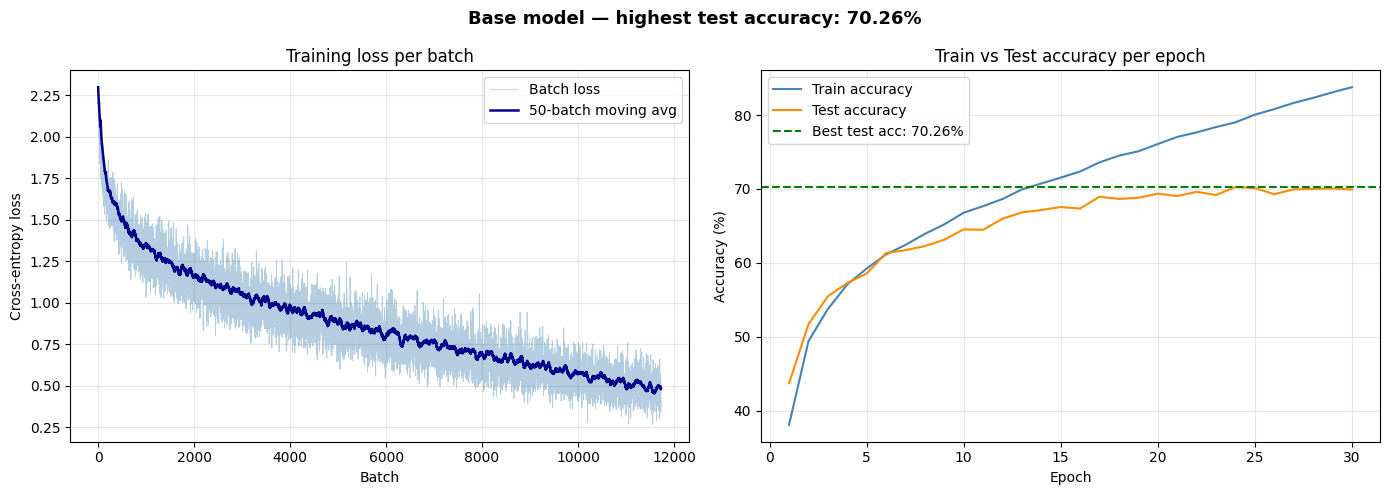

Highest test accuracy: 70.26%


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: loss per training batch ───────────────────────────────────────
ax = axes[0]
ax.plot(batch_losses_all, linewidth=0.6, alpha=0.4, color='steelblue', label='Batch loss')

# Rolling average to show trend
window = 50
if len(batch_losses_all) >= window:
    smoothed = [sum(batch_losses_all[max(0, i-window):i+1]) / min(i+1, window)
                for i in range(len(batch_losses_all))]
    ax.plot(smoothed, linewidth=1.8, color='darkblue', label=f'{window}-batch moving avg')

ax.set_xlabel('Batch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Training loss per batch')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: train / test accuracy per epoch ───────────────────────────────
ax = axes[1]
epochs = range(1, len(train_accs) + 1)
ax.plot(epochs, [a * 100 for a in train_accs], label='Train accuracy', color='steelblue')
ax.plot(epochs, [a * 100 for a in test_accs],  label='Test accuracy',  color='darkorange')
ax.axhline(best_test_acc * 100, color='green', linestyle='--',
           label=f'Best test acc: {best_test_acc*100:.2f}%')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Train vs Test accuracy per epoch')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f"Base model — highest test accuracy: {best_test_acc*100:.2f}%", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('base_model_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Highest test accuracy: {best_test_acc*100:.2f}%')
